In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle

df_eddies = pd.read_pickle('/srv/scratch/z5297792/Chapter2/SEACOFS_26yr_Eddy_Dataset/Eddy_Data/df_eddies_processed_1462_10650.pkl')
df_tilt_data = pd.read_pickle("/srv/scratch/z5297792/Chapter2/SEACOFS_26yr_Eddy_Dataset/Eddy_Data/Vertical_Eddy_Dataset/df_tilt_data.pkl")
df_eddies = df_eddies.merge(
    df_tilt_data[['Eddy', 'Day', 'TiltDis', 'TiltDir']],
    how='left',
    left_on=['Eddy', 'Day'],
    right_on=['Eddy', 'Day']
)

with open('/srv/scratch/z5297792/Chapter2/SEACOFS_26yr_Eddy_Dataset/Eddy_Data/Vertical_Eddy_Dataset/dic_vert_eddies.pkl', 'rb') as f:
    dic_eddies_vert = pickle.load(f)
    

In [2]:
sample_eddies = [66, 425, 871, 1780, 31, 182, 1602, 2128]

dic_sample = {}
for eddy in sample_eddies:
    eddy = f'Eddy{eddy}'
    dic_sample[eddy] = dic_eddies_vert[eddy]
    

In [23]:
import netCDF4 as nc
from scipy.interpolate import griddata
from scipy.interpolate import RegularGridInterpolator

fname = f'/srv/scratch/z3533156/26year_BRAN2020/outer_avg_01461.nc'
dataset = nc.Dataset(fname)
lon_rho = np.transpose(dataset.variables['lon_rho'], axes=(1, 0))
lat_rho = np.transpose(dataset.variables['lat_rho'], axes=(1, 0))
mask_rho = np.transpose(dataset.variables['mask_rho'], axes=(1, 0))
h =  np.transpose(dataset.variables['h'], axes=(1, 0))
angle = dataset.variables['angle'][0, 0]
z_r = np.load('/srv/scratch/z5297792/z_r.npy')
z_r = np.transpose(z_r, (1, 2, 0))
def distance(lat1, lon1, lat2, lon2):
    EARTH_RADIUS = 6357
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return EARTH_RADIUS * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
j_mid = lon_rho.shape[1] // 2
i_mid = lon_rho.shape[0] // 2
dx = distance(lat_rho[:-1, j_mid], lon_rho[:-1, j_mid],
              lat_rho[1:, j_mid], lon_rho[1:, j_mid])
dy = distance(lat_rho[i_mid, :-1], lon_rho[i_mid, :-1],
              lat_rho[i_mid, 1:], lon_rho[i_mid, 1:])
x_grid = np.insert(np.cumsum(dx), 0, 0)
y_grid = np.insert(np.cumsum(dy), 0, 0)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid, indexing='ij')

dataset.variables['w']


<class 'netCDF4.Variable'>
float32 w(ocean_time, s_w, eta_rho, xi_rho)
    long_name: time-averaged vertical momentum component
    units: meter second-1
    time: ocean_time
    standard_name: upward_sea_water_velocity
    grid: grid
    location: face
    coordinates: lon_rho lat_rho s_w ocean_time
    field: w-velocity, scalar, series
    _FillValue: 1e+37
unlimited dimensions: ocean_time
current shape = (30, 31, 317, 272)
filling on

In [4]:
mask = np.abs(z_r[150, 150, :]) < 1000
depth = np.abs(z_r[150, 150, :][mask])
n = depth.size

base = pd.DataFrame({"Depth": depth})
frames = []

for eddy, dic in dic_sample.items():
    for d, (df, day) in enumerate(zip(dic.values(), dic.keys())):
        if df.empty:
            continue
        day = int(day[3:])
        df2 = df.loc[df["Depth"].abs() < 1000, ["x", "y"]].reset_index(drop=True)
        tmp = df2.reindex(range(n))  # pad with NaNs to match depth levels
        tmp.columns = [f"{eddy}_Day{day}_x", f"{eddy}_Day{day}_y"]
        frames.append(tmp)

df_depths = pd.concat([base, *frames], axis=1, copy=False)
df_depths


,Depth,Eddy66_Day1674_x,Eddy66_Day1674_y,Eddy66_Day1675_x,Eddy66_Day1675_y,Eddy66_Day1676_x,Eddy66_Day1676_y,Eddy66_Day1679_x,Eddy66_Day1679_y,Eddy66_Day1680_x,...,Eddy2128_Day8966_x,Eddy2128_Day8966_y,Eddy2128_Day8967_x,Eddy2128_Day8967_y,Eddy2128_Day8968_x,Eddy2128_Day8968_y,Eddy2128_Day8969_x,Eddy2128_Day8969_y,Eddy2128_Day8970_x,Eddy2128_Day8970_y
0,1.783320,838.082945,1463.359042,841.944207,1458.453989,845.647270,1457.132245,844.231507,1488.502854,839.416705,...,253.084486,567.480090,241.881085,536.699813,238.604963,523.279677,240.586005,517.400123,242.627058,498.439709
1,5.879627,838.449025,1462.889245,842.548504,1458.370782,846.492748,1457.401894,844.139211,1487.952266,839.914092,...,247.609623,560.154560,240.715586,532.490102,238.290099,522.534501,239.280399,516.258631,243.434436,499.768934
2,10.725783,838.490020,1462.700349,842.953076,1458.517750,846.865130,1457.608137,844.148262,1487.665062,840.245640,...,246.281557,545.042801,240.745331,532.123683,238.367262,522.731495,239.246365,516.226479,243.800521,500.998354
3,16.383097,838.643865,1462.945791,843.346376,1458.755273,847.123878,1457.839066,844.146417,1487.423538,840.456378,...,243.799958,535.565244,240.616023,531.272790,238.396574,522.900646,239.201841,516.231714,243.843124,502.265386
4,22.925581,838.758631,1462.524487,843.581149,1458.630220,847.346424,1458.110049,844.146634,1487.093842,840.741524,...,243.910670,532.647053,240.598377,530.937821,238.286392,522.686191,239.195147,516.253579,243.571661,503.336370
5,30.444118,838.899192,1462.704843,843.973783,1459.065805,848.195131,1460.480151,844.096139,1486.861545,840.803457,...,243.769833,530.865328,240.644250,530.863947,238.164996,522.375225,239.006638,516.161120,243.011629,503.642985
6,39.052712,839.117184,1462.531297,844.352940,1459.700432,848.259160,1462.114486,844.007418,1486.672237,840.963613,...,243.670698,529.715716,240.596766,530.618297,238.173968,522.198867,238.825620,516.215450,242.030140,503.900624
7,48.897638,839.480305,1462.474008,844.380259,1461.188048,848.335503,1462.858759,843.788228,1486.529163,841.421390,...,243.619169,529.028098,240.506829,530.299263,238.209823,522.420784,238.481207,516.020812,241.513391,503.474732
8,60.170639,840.037014,1462.728148,844.866533,1462.552153,848.400615,1465.279241,843.360048,1486.256158,841.036146,...,243.535369,528.354243,240.444449,530.076358,238.148097,522.564441,238.168532,515.534681,241.119982,502.661505
9,73.127842,841.301853,1463.629237,845.664766,1464.587517,848.068300,1469.311099,842.087392,1485.073831,842.182898,...,243.429020,527.584898,240.481575,530.022219,237.992685,522.612111,238.053530,515.256108,240.797998,502.139416


In [9]:
def add_center_temp_columns(
    df_depths,
    df_eddies,
    X_grid,
    Y_grid,
    mask_rho,
    z_r,
    varname="w",
    depth_max=1000
):
    X = np.asarray(X_grid)
    Y = np.asarray(Y_grid)
    wet = np.asarray(mask_rho).astype(bool)
    shp = X.shape

    # target depths (1D)
    if "Depth" in df_depths.columns:
        depth_all = np.abs(df_depths["Depth"].to_numpy(dtype=float))
    elif "z" in df_depths.columns:
        depth_all = np.abs(df_depths["z"].to_numpy(dtype=float))
    else:
        zr = np.abs(np.asarray(z_r, float))
        zr = np.where(wet[:, :, None], zr, np.nan)
        depth_all = np.nanmedian(zr, axis=(0, 1))

    depth_all = np.asarray(depth_all, float)
    keep = np.isfinite(depth_all) & (depth_all <= depth_max)
    depth = depth_all[keep]
    n = depth.size

    # nearest wet (i,j)
    Xf = X[wet].ravel()
    Yf = Y[wet].ravel()
    wet_idx = np.flatnonzero(wet)

    try:
        from scipy.spatial import cKDTree
        tree = cKDTree(np.c_[Xf, Yf])

        def nearest_ij(xc, yc):
            _, k = tree.query([xc, yc])
            return np.unravel_index(wet_idx[k], shp)
    except Exception:
        def nearest_ij(xc, yc):
            d2 = (Xf - xc) ** 2 + (Yf - yc) ** 2
            k = int(np.nanargmin(d2))
            return np.unravel_index(wet_idx[k], shp)

    # only compute if TiltDis exists
    valid_pairs = set(
        df_eddies.loc[~df_eddies["TiltDis"].isna(), ["Eddy", "Day"]]
        .itertuples(index=False, name=None)
    )

    key2fname = (
        df_eddies[["Eddy", "Day", "fname"]]
        .dropna(subset=["fname"])
        .drop_duplicates(["Eddy", "Day"])
        .set_index(["Eddy", "Day"])["fname"]
    )

    # abs depth of sigma surfaces: (x,y,s)
    zr_abs = np.abs(np.asarray(z_r, float))
    zr_abs = np.where(wet[:, :, None], zr_abs, np.nan)

    temp_cache = {}
    cols = {}

    def interp_profile_at_depth(zprof, vprof, d):
        zprof = np.asarray(zprof, float).ravel()
        vprof = np.asarray(vprof, float).ravel()
        m = np.isfinite(zprof) & np.isfinite(vprof)
        if m.sum() == 0:
            return np.nan
        if m.sum() == 1:
            return float(vprof[m][0])

        z = zprof[m]
        v = vprof[m]
        o = np.argsort(z)
        z = z[o]
        v = v[o]

        if d <= z[0]:
            return float(v[0])
        if d >= z[-1]:
            return float(v[-1])
        return float(np.interp(d, z, v))

    for col in df_depths.columns:
        if not col.endswith("_x"):
            continue

        base = col[:-2]
        ycol = base + "_y"
        out_temp = base + "_w"

        try:
            eddy = int(base.split("_Day")[0].replace("Eddy", ""))
            day = int(base.split("_Day")[1])
        except Exception:
            continue

        if (eddy, day) not in valid_pairs:
            continue
        if (eddy, day) not in key2fname.index:
            continue

        fname = str(key2fname.loc[(eddy, day)])
        fnumber = int(fname[-8:-3])
        base_day = fnumber + 1
        t_idx = int(day - base_day)

        if fname not in temp_cache:
            ds = nc.Dataset(fname)
            tempv = ds.variables[varname]
            temp_arr = np.transpose(tempv, axes=(3, 2, 1, 0))  # -> (x,y,s,t)
            temp_arr = np.flip(temp_arr, axis=2)
            temp_arr = np.where(wet[:, :, None, None], temp_arr, np.nan)
            if varname == 'w':
                temp_arr = temp_arr[:,:,1:,:]
            temp_cache[fname] = temp_arr
            ds.close()

        temp = temp_cache[fname]
        if t_idx < 0 or t_idx >= temp.shape[3]:
            continue

        xs = df_depths[col].to_numpy(dtype=float)[keep]
        ys = df_depths[ycol].to_numpy(dtype=float)[keep]

        vals_temp = np.full(n, np.nan)

        kk = np.flatnonzero(np.isfinite(xs) & np.isfinite(ys) & np.isfinite(depth))

        for k in kk:
            i, j = nearest_ij(xs[k], ys[k])

            zprof = zr_abs[i, j, :]
            tprof = temp[i, j, :, t_idx]

            t_at_d = interp_profile_at_depth(zprof, tprof, depth[k])

            vals_temp[k] = t_at_d

        cols[out_temp] = vals_temp

    df_temps = pd.concat(
        [pd.DataFrame({"Depth": depth}), pd.DataFrame(cols)],
        axis=1
    )
    return df_temps


In [13]:
df_ws = add_center_temp_columns(
    df_depths,
    df_eddies,
    X_grid,
    Y_grid,
    mask_rho,
    z_r,
    varname="w",
    depth_max=1000
)


In [15]:
df_ws


,Depth,Eddy66_Day1679_w,Eddy66_Day1680_w,Eddy66_Day1681_w,Eddy66_Day1682_w,Eddy66_Day1683_w,Eddy66_Day1684_w,Eddy66_Day1691_w,Eddy66_Day1692_w,Eddy66_Day1693_w,...,Eddy2128_Day8957_w,Eddy2128_Day8958_w,Eddy2128_Day8959_w,Eddy2128_Day8960_w,Eddy2128_Day8961_w,Eddy2128_Day8962_w,Eddy2128_Day8963_w,Eddy2128_Day8964_w,Eddy2128_Day8966_w,Eddy2128_Day8967_w
0,1.783320,3.371023e-07,0.000010,0.000011,0.000013,0.000007,0.000005,-0.000002,1.590416e-05,-0.000003,...,0.000003,2.526192e-06,4.061405e-06,-5.878325e-07,-1.562671e-06,-0.000004,-0.000003,-0.000005,0.000018,6.045189e-06
1,5.879627,-1.711299e-06,0.000020,0.000023,0.000029,0.000019,0.000014,-0.000007,2.254366e-06,-0.000009,...,0.000005,2.193173e-06,3.867583e-06,-6.630350e-07,-1.603750e-06,-0.000006,-0.000003,-0.000007,-0.000021,4.396185e-06
2,10.725783,-4.383995e-06,0.000052,0.000037,0.000048,0.000032,0.000025,-0.000013,-1.431302e-06,-0.000016,...,0.000005,1.434957e-06,5.414945e-06,-8.678905e-07,-7.363779e-07,-0.000006,-0.000003,-0.000010,-0.000089,3.088628e-06
3,16.383097,-7.805082e-06,0.000072,0.000053,0.000068,0.000046,0.000038,-0.000021,5.099175e-07,-0.000025,...,0.000004,1.609250e-06,1.138842e-05,-7.266761e-07,6.080234e-07,-0.000008,-0.000004,-0.000010,-0.000057,1.386964e-06
4,22.925581,-1.190235e-05,0.000094,0.000069,0.000090,0.000062,0.000051,-0.000029,-9.959223e-07,0.000028,...,0.000003,7.774906e-07,8.647059e-06,3.033035e-07,1.436514e-05,-0.000011,-0.000004,-0.000012,-0.000009,-9.240264e-07
5,30.444118,-1.673162e-05,0.000114,0.000087,0.000112,0.000083,0.000064,-0.000038,-3.003694e-06,0.000032,...,-0.000005,-3.976075e-07,1.063605e-05,-7.997533e-06,2.018854e-05,-0.000018,-0.000005,-0.000021,0.000007,-4.559939e-06
6,39.052712,-2.228659e-05,0.000132,0.000092,0.000134,0.000100,0.000076,-0.000047,-5.483069e-06,0.000036,...,-0.000009,-2.148802e-06,1.268122e-05,-9.006865e-06,2.590158e-05,-0.000018,-0.000021,-0.000025,0.000009,-8.308006e-06
7,48.897638,-2.842348e-05,-0.000002,0.000123,0.000155,0.000115,0.000085,-0.000056,2.971696e-05,-0.000069,...,-0.000015,-4.520980e-06,4.241172e-06,-1.075722e-05,3.152024e-05,-0.000022,-0.000023,-0.000029,0.000015,-1.018839e-05
8,60.170639,-4.377146e-05,0.000149,0.000157,0.000172,0.000125,0.000089,-0.000065,3.836530e-05,-0.000080,...,-0.000022,-7.310070e-06,4.109135e-06,-1.372453e-05,3.704068e-05,-0.000025,-0.000030,-0.000033,0.000025,3.537298e-05
9,73.127842,-5.784296e-05,0.000132,0.000170,0.000183,0.000130,0.000085,-0.000072,4.891244e-05,-0.000090,...,-0.000031,-1.195435e-05,3.336795e-06,-1.639951e-05,4.236357e-05,-0.000028,-0.000035,-0.000031,0.000039,3.820966e-05


positive w is upwards velocity


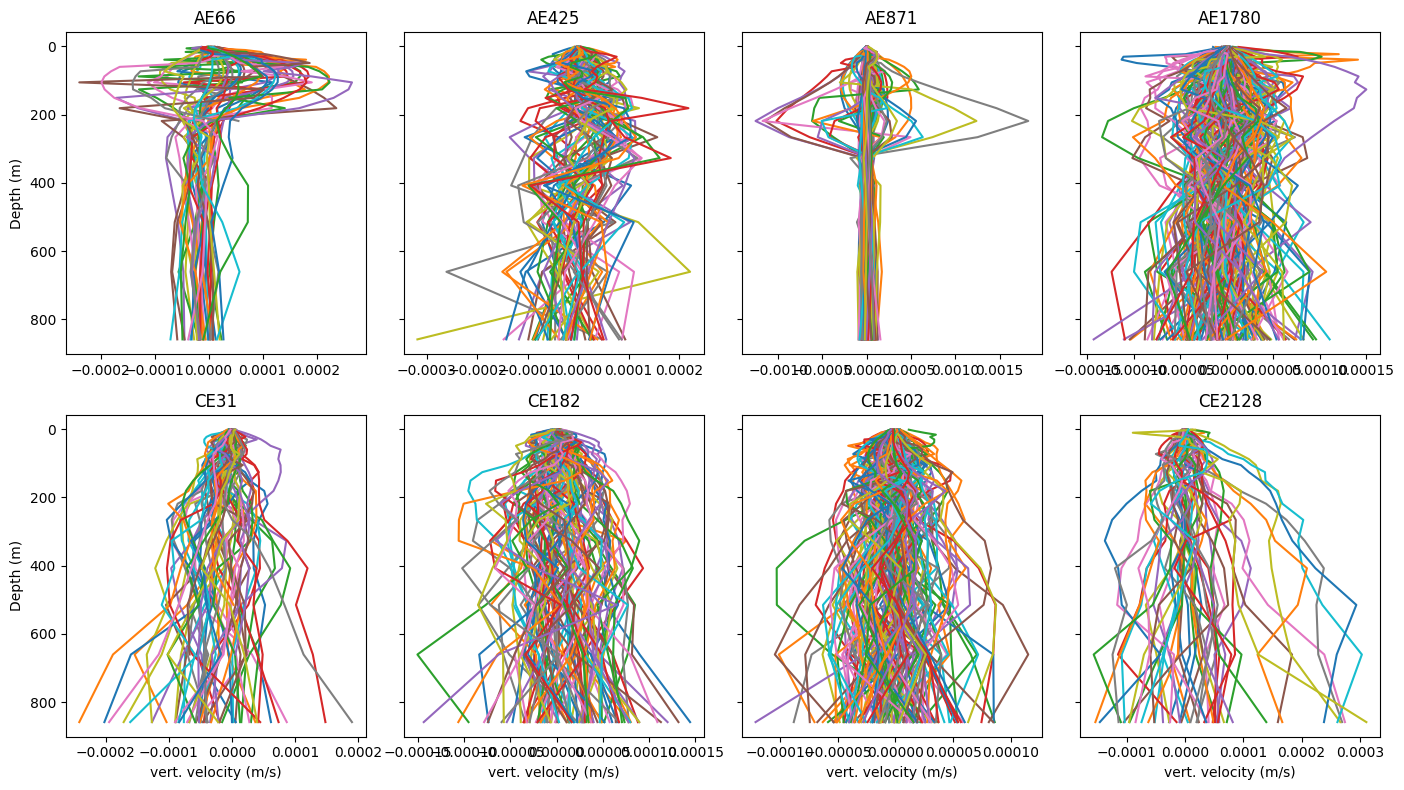

In [25]:
fig, axs = plt.subplots(2, 4, sharey=True, sharex=False, figsize=(14,8))
axs = axs.flatten()
for k, n2col in enumerate(df_ws.columns):
    if k != 0:
        eddy_id = int(n2col.split("_")[0].replace("Eddy", ""))
        p = np.where([eddy_id==i for i in sample_eddies])[0][0]
        if n2col.endswith("_w"):
            axs[p].plot(df_ws[f'{n2col}'], df_ws.Depth)
        cyc = df_eddies[df_eddies.Eddy==eddy_id].Cyc.iloc[0]
        axs[p].set_title(f'{cyc}{eddy_id}')
axs[0].invert_yaxis()
for a, ax in enumerate(axs.flatten()):
    if a >= 4:
        ax.set_xlabel('vert. velocity (m/s)')
axs[0].set_ylabel('Depth (m)'); axs[4].set_ylabel('Depth (m)');
plt.tight_layout()
print('positive w is upwards velocity')


In [34]:
def add_center_temp_core_columns(
    df_depths,
    df_eddies,
    X_grid,
    Y_grid,
    mask_rho,
    z_r,
    varname="w",
    depth_max=1000,
    radius_km=50.0,
    min_pts=1
):
    X = np.asarray(X_grid, float)
    Y = np.asarray(Y_grid, float)
    wet = np.asarray(mask_rho).astype(bool)
    shp = X.shape

    if "Depth" in df_depths.columns:
        depth_all = np.abs(df_depths["Depth"].to_numpy(dtype=float))
    elif "z" in df_depths.columns:
        depth_all = np.abs(df_depths["z"].to_numpy(dtype=float))
    else:
        zr = np.abs(np.asarray(z_r, float))
        zr = np.where(wet[:, :, None], zr, np.nan)
        depth_all = np.nanmedian(zr, axis=(0, 1))

    depth_all = np.asarray(depth_all, float)
    keep = np.isfinite(depth_all) & (depth_all <= depth_max)
    depth = depth_all[keep]
    n = depth.size

    Xf = X[wet].ravel()
    Yf = Y[wet].ravel()
    wet_idx = np.flatnonzero(wet)

    r = float(radius_km)

    try:
        from scipy.spatial import cKDTree
        tree = cKDTree(np.c_[Xf, Yf])

        def ij_within_radius(xc, yc):
            ks = tree.query_ball_point([xc, yc], r)
            if not ks:
                return None
            ij = np.array([np.unravel_index(wet_idx[k], shp) for k in ks], dtype=int)
            return ij[:, 0], ij[:, 1]
    except Exception:
        def ij_within_radius(xc, yc):
            d2 = (Xf - xc) ** 2 + (Yf - yc) ** 2
            ks = np.flatnonzero(d2 <= r * r)
            if ks.size == 0:
                return None
            ij = np.array([np.unravel_index(wet_idx[k], shp) for k in ks], dtype=int)
            return ij[:, 0], ij[:, 1]

    valid_pairs = set(
        df_eddies.loc[~df_eddies["TiltDis"].isna(), ["Eddy", "Day"]]
        .itertuples(index=False, name=None)
    )

    key2fname = (
        df_eddies[["Eddy", "Day", "fname"]]
        .dropna(subset=["fname"])
        .drop_duplicates(["Eddy", "Day"])
        .set_index(["Eddy", "Day"])["fname"]
    )

    zr_abs = np.abs(np.asarray(z_r, float))
    zr_abs = np.where(wet[:, :, None], zr_abs, np.nan)

    temp_cache = {}
    cols = {}

    def interp_profile_at_depth(zprof, vprof, d):
        zprof = np.asarray(zprof, float).ravel()
        vprof = np.asarray(vprof, float).ravel()
        m = np.isfinite(zprof) & np.isfinite(vprof)
        if m.sum() == 0:
            return np.nan
        if m.sum() == 1:
            return float(vprof[m][0])
        z = zprof[m]
        v = vprof[m]
        o = np.argsort(z)
        z = z[o]
        v = v[o]
        if d <= z[0]:
            return float(v[0])
        if d >= z[-1]:
            return float(v[-1])
        return float(np.interp(d, z, v))

    def mean_within_radius_at_depth(ii, jj, d, temp3d_t):
        vals = np.full(ii.size, np.nan, float)
        for p in range(ii.size):
            i = ii[p]; j = jj[p]
            vals[p] = interp_profile_at_depth(zr_abs[i, j, :], temp3d_t[i, j, :], d)
        m = np.isfinite(vals)
        if m.sum() < min_pts:
            return np.nan
        return float(np.nanmean(vals[m]))

    for col in df_depths.columns:
        if not col.endswith("_x"):
            continue

        base = col[:-2]
        ycol = base + "_y"
        out_temp = base + f"_{varname}"

        try:
            eddy = int(base.split("_Day")[0].replace("Eddy", ""))
            day = int(base.split("_Day")[1])
        except Exception:
            continue

        if (eddy, day) not in valid_pairs:
            continue
        if (eddy, day) not in key2fname.index:
            continue

        fname = str(key2fname.loc[(eddy, day)])
        fnumber = int(fname[-8:-3])
        base_day = fnumber + 1
        t_idx = int(day - base_day)

        if fname not in temp_cache:
            ds = nc.Dataset(fname)
            v = ds.variables[varname]
            arr = np.transpose(v, axes=(3, 2, 1, 0))  # (x,y,s,t)
            arr = np.flip(arr, axis=2)
            arr = np.where(wet[:, :, None, None], arr, np.nan)
            if varname == "w":
                arr = arr[:, :, 1:, :]
            temp_cache[fname] = arr
            ds.close()

        temp = temp_cache[fname]
        if t_idx < 0 or t_idx >= temp.shape[3]:
            continue

        xs = df_depths[col].to_numpy(dtype=float)[keep]
        ys = df_depths[ycol].to_numpy(dtype=float)[keep]

        vals_out = np.full(n, np.nan)
        kk = np.flatnonzero(np.isfinite(xs) & np.isfinite(ys) & np.isfinite(depth))

        temp3d_t = temp[:, :, :, t_idx]  # (x,y,s)

        for k in kk:
            ij = ij_within_radius(xs[k], ys[k])
            if ij is None:
                continue
            ii, jj = ij
            vals_out[k] = mean_within_radius_at_depth(ii, jj, depth[k], temp3d_t)

        cols[out_temp] = vals_out

    df_out = pd.concat([pd.DataFrame({"Depth": depth}), pd.DataFrame(cols)], axis=1)
    return df_out


In [36]:
df_core_ws = add_center_temp_core_columns(
    df_depths,
    df_eddies,
    X_grid,
    Y_grid,
    mask_rho,
    z_r,
    varname="w",
    depth_max=1000,
    radius_km=50,
    min_pts=1
)


In [37]:
df_core_ws


,Depth,Eddy66_Day1679_w,Eddy66_Day1680_w,Eddy66_Day1681_w,Eddy66_Day1682_w,Eddy66_Day1683_w,Eddy66_Day1684_w,Eddy66_Day1691_w,Eddy66_Day1692_w,Eddy66_Day1693_w,...,Eddy2128_Day8957_w,Eddy2128_Day8958_w,Eddy2128_Day8959_w,Eddy2128_Day8960_w,Eddy2128_Day8961_w,Eddy2128_Day8962_w,Eddy2128_Day8963_w,Eddy2128_Day8964_w,Eddy2128_Day8966_w,Eddy2128_Day8967_w
0,1.783320,3.413514e-06,0.000003,2.208393e-06,1.165400e-06,-9.997751e-07,-0.000003,3.248822e-06,2.537716e-06,0.000002,...,-0.000002,-0.000004,-0.000005,-0.000004,-1.796742e-06,-3.998239e-06,-0.000006,-0.000008,-1.727436e-06,6.233026e-07
1,5.879627,3.751034e-06,0.000003,3.113817e-06,3.572105e-06,5.008188e-07,-0.000003,3.746542e-06,2.673529e-06,0.000003,...,-0.000007,-0.000012,-0.000015,-0.000008,-1.754959e-06,-5.871056e-06,-0.000011,-0.000014,-4.283532e-07,1.236702e-06
2,10.725783,4.791982e-06,0.000004,5.182761e-06,5.943667e-06,1.809878e-06,-0.000003,4.164240e-06,2.921232e-06,0.000003,...,-0.000014,-0.000020,-0.000024,-0.000013,-3.142602e-07,-7.331501e-06,-0.000016,-0.000023,4.174836e-07,2.122721e-06
3,16.383097,5.632340e-06,0.000006,7.208663e-06,8.784005e-06,2.870794e-06,-0.000003,4.186948e-06,3.020794e-06,0.000004,...,-0.000020,-0.000028,-0.000034,-0.000018,2.118398e-06,-8.482815e-06,-0.000023,-0.000033,3.737808e-06,3.614149e-06
4,22.925581,7.968369e-06,0.000007,9.409102e-06,1.181530e-05,4.359689e-06,-0.000004,4.533619e-06,3.315652e-06,0.000003,...,-0.000027,-0.000034,-0.000041,-0.000022,5.180575e-06,-1.013525e-05,-0.000028,-0.000043,7.445312e-06,5.083640e-06
5,30.444118,1.018020e-05,0.000010,1.151431e-05,1.495109e-05,6.407612e-06,-0.000004,4.148424e-06,2.954959e-06,0.000004,...,-0.000033,-0.000038,-0.000046,-0.000024,7.871207e-06,-9.426450e-06,-0.000033,-0.000053,1.217050e-05,6.757182e-06
6,39.052712,1.167945e-05,0.000009,1.372384e-05,1.841497e-05,6.225290e-06,-0.000002,4.308605e-06,3.193888e-06,0.000002,...,-0.000040,-0.000042,-0.000047,-0.000025,1.125506e-05,-7.041138e-06,-0.000034,-0.000061,1.806038e-05,8.467911e-06
7,48.897638,1.176127e-05,0.000011,1.631197e-05,2.115795e-05,7.187977e-06,-0.000003,3.810047e-06,2.900054e-06,0.000002,...,-0.000045,-0.000047,-0.000047,-0.000024,1.459460e-05,-5.023935e-06,-0.000031,-0.000067,2.607474e-05,9.398830e-06
8,60.170639,1.135087e-05,0.000011,1.800605e-05,2.284231e-05,9.717737e-06,-0.000004,3.471330e-06,2.737600e-06,-0.000002,...,-0.000052,-0.000050,-0.000049,-0.000024,1.816322e-05,-2.947322e-06,-0.000027,-0.000071,3.104275e-05,9.653639e-06
9,73.127842,3.725943e-06,0.000011,1.804973e-05,2.408222e-05,6.754656e-06,-0.000008,2.734800e-06,1.858341e-06,-0.000003,...,-0.000058,-0.000050,-0.000047,-0.000024,2.272764e-05,2.935807e-07,-0.000023,-0.000072,3.561877e-05,9.634529e-06


positive w is upwards velocity


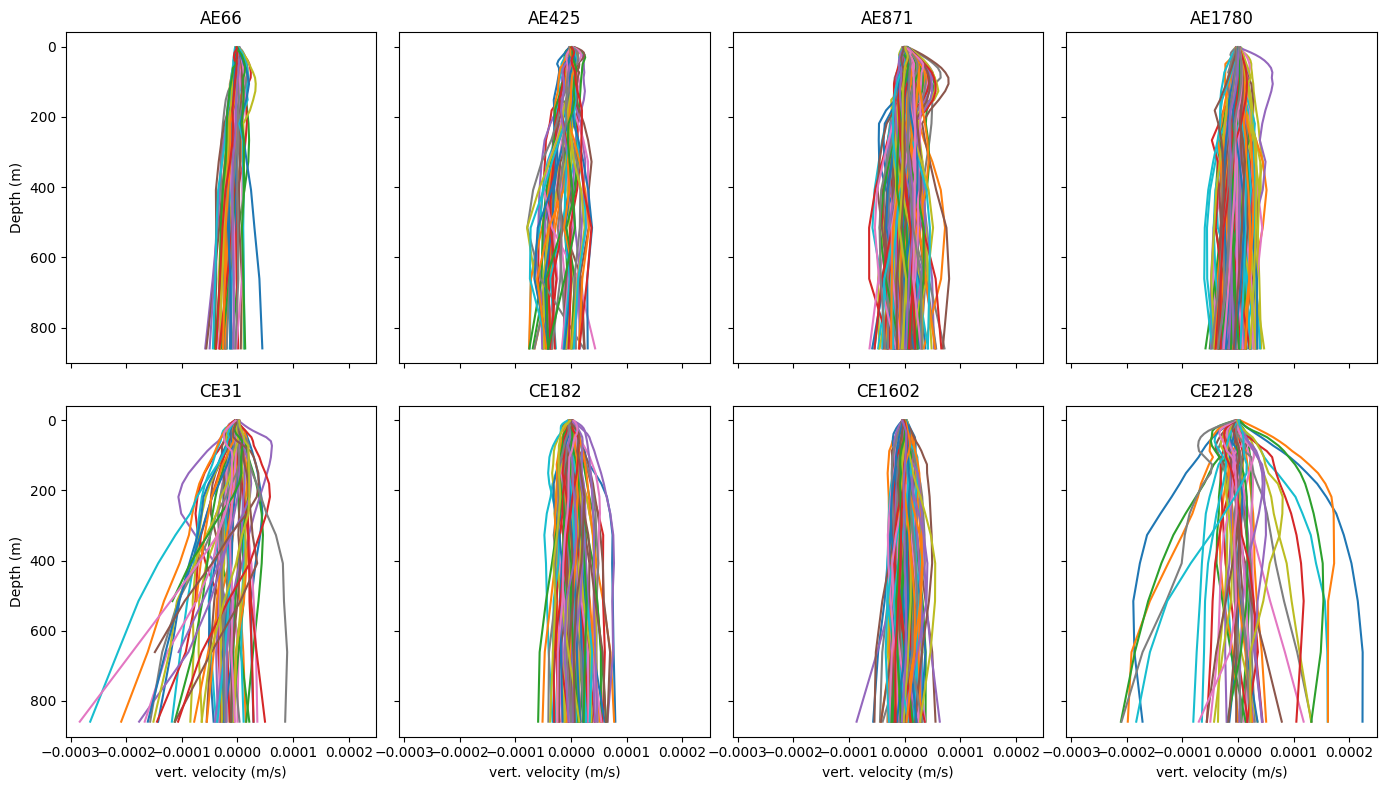

In [39]:
fig, axs = plt.subplots(2, 4, sharey=True, sharex=True, figsize=(14,8))
axs = axs.flatten()
for k, n2col in enumerate(df_core_ws.columns):
    if k != 0:
        eddy_id = int(n2col.split("_")[0].replace("Eddy", ""))
        p = np.where([eddy_id==i for i in sample_eddies])[0][0]
        if n2col.endswith("_w"):
            axs[p].plot(df_core_ws[f'{n2col}'], df_core_ws.Depth)
        cyc = df_eddies[df_eddies.Eddy==eddy_id].Cyc.iloc[0]
        axs[p].set_title(f'{cyc}{eddy_id}')
axs[0].invert_yaxis()
for a, ax in enumerate(axs.flatten()):
    if a >= 4:
        ax.set_xlabel('vert. velocity (m/s)')
axs[0].set_ylabel('Depth (m)'); axs[4].set_ylabel('Depth (m)');
plt.tight_layout()
print('positive w is upwards velocity')
